                                                   text  spam
0     Subject: naturally irresistible your corporate...     1
1     Subject: the stock trading gunslinger  fanny i...     1
2     Subject: unbelievable new homes made easy  im ...     1
3     Subject: 4 color printing special  request add...     1
4     Subject: do not have money , get software cds ...     1
...                                                 ...   ...
5723  Subject: re : research and development charges...     0
5724  Subject: re : receipts from visit  jim ,  than...     0
5725  Subject: re : enron case study update  wow ! a...     0
5726  Subject: re : interest  david ,  please , call...     0
5727  Subject: news : aurora 5 . 2 update  aurora ve...     0

[5728 rows x 2 columns]
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...  

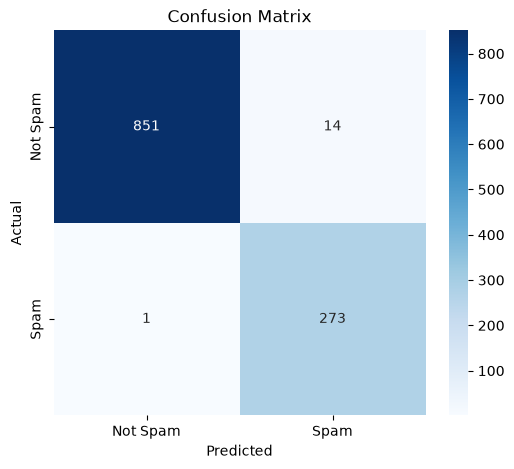

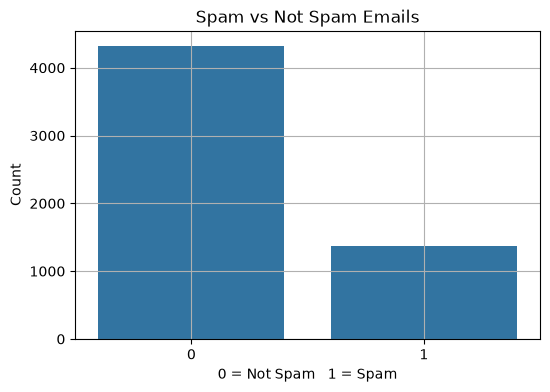

Prediction: [1]
Prediction value: 1
Spam Email


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
df = pd.read_csv("emails.csv")
print(df)
print(df.head())
print(df.tail())

print(df.shape)

print(df.info())

print(df.isnull().sum())

# ==========================================
# Remove Missing Values using SimpleImputer
# ==========================================

imputer = SimpleImputer(strategy="most_frequent")

df[["text"]] = imputer.fit_transform(df[["text"]])

print(df.isnull().sum())

# ==========================================
# Remove Duplicate Rows
# ==========================================

df.drop_duplicates(inplace=True)

# ==========================================
# Feature and Target
# =========================================
X = df["text"]

y = df["spam"]

df = df[df["spam"].isin([0, 1])]

X = df["text"]
y = df["spam"]




# ==========================================
# Split Dataset
# ==========================================


X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# Convert Text into Numbers
# ==========================================

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)

# ==========================================
# Train Logistic Regression Model
# ==========================================

model = LogisticRegression(class_weight="balanced",
    max_iter=1000
    
)

model.fit(X_train, y_train)

# ==========================================
# Save Model and Vectorizer
# ==========================================

joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

# ==========================================
# Prediction
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Spam","Spam"],
    yticklabels=["Not Spam","Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================
# Spam vs Not Spam
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x="spam", data=df)

plt.title("Spam vs Not Spam Emails")
plt.xlabel("0 = Not Spam   1 = Spam")
plt.ylabel("Count")

plt.grid()

plt.show()

# ==========================================
# Custom Prediction
# ==========================================

email = input("Enter Email:\n")

email = vectorizer.transform([email])

prediction = model.predict(email)
print("Prediction:", prediction)
print("Prediction value:", prediction[0])


if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

In [8]:
print(y.value_counts())

spam
0    4325
1    1368
Name: count, dtype: int64


In [12]:
import os

print(os.listdir())
print(os.path.isdir("emails.csv"))
print(os.path.isfile("emails.csv"))

['.venv', 'emails.csv', 'nb.ipynb', 'requirement.txt', 'spam_model.pkl', 'templates', 'tfidf_vectorizer.pkl']
False
True


In [17]:
print(df.columns.tolist())
print(df.head())

[]
Empty DataFrame
Columns: []
Index: []


In [4]:
import os

print(os.path.abspath("emails1.csv"))

c:\Users\Sharma Computers\OneDrive\Desktop\Spam email\emails1.csv


In [9]:
print(os.path.getsize("emails1.csv"))

8954755


In [15]:
df = pd.read_csv("emails.csv")

print(df.columns.tolist())
print(df.shape)
print(df.head(3))

['text', 'spam']
(5728, 2)
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
